In [67]:
# %%
from pathlib import Path
import json

import sys
from pathlib import Path


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


ROOT = Path("/home/hschatzle/monte-carlo-selection")
sys.path.append(str(ROOT))
from shapely.geometry import Point, Polygon
from scripts.shape_gen.intersections2 import find_intersection_points_multiple

In [68]:
# %%
CASE_ID = "bird_136_symmetrical_8_1"

RESULTS_DIR = Path("/home/hschatzle/monte-carlo-selection/results/sweep/bgmm_bird_136_symmetrical_shape_8") / CASE_ID
GEOM_DIR = Path("/home/hschatzle/monte-carlo-selection/data/cases/sweep") / CASE_ID

case_jsonl_path = GEOM_DIR / "generated" / f"{CASE_ID}.jsonl"
shapes_npz_path = GEOM_DIR / "generated" / "shapes_xy.npz"
top10_jsonl_path = RESULTS_DIR / "top10_clusters.jsonl"

N_POINTS_SHAPE = 1024
N_POINTS_OCCLUDER = 256
N_ARC = 250
TOP_N = 200

In [69]:
# %%
def polygon_to_xy(poly, drop_duplicate_endpoint=True):
    xy = np.asarray(poly, dtype=float)
    if drop_duplicate_endpoint and len(xy) >= 2 and np.allclose(xy[0], xy[-1]):
        xy = xy[:-1]
    return xy


def signed_area(xy):
    xy = np.asarray(xy, dtype=float)
    if len(xy) < 3:
        return 0.0
    if not np.allclose(xy[0], xy[-1]):
        xy = np.vstack([xy, xy[0]])
    x = xy[:, 0]
    y = xy[:, 1]
    return 0.5 * np.sum(x[:-1] * y[1:] - x[1:] * y[:-1])


def ensure_ccw(xy):
    xy = np.asarray(xy, dtype=float)
    if signed_area(xy) < 0:
        return xy[::-1].copy()
    return xy.copy()


def resample_contour_arc_length(xy, n_points=256, closed=True):
    xy = np.asarray(xy, dtype=float)

    if len(xy) < 2:
        raise ValueError("Contour must contain at least 2 points.")

    if closed and not np.allclose(xy[0], xy[-1]):
        xy = np.vstack([xy, xy[0]])

    seg = np.diff(xy, axis=0)
    seglen = np.sqrt((seg ** 2).sum(axis=1))

    keep = seglen > 1e-12
    if not np.all(keep):
        xy = np.vstack([xy[0], xy[1:][keep]])
        seg = np.diff(xy, axis=0)
        seglen = np.sqrt((seg ** 2).sum(axis=1))

    if len(seglen) == 0 or np.sum(seglen) <= 1e-12:
        raise ValueError("Contour has zero total arc length after removing duplicate points.")

    cum = np.concatenate([[0.0], np.cumsum(seglen)])
    total = float(cum[-1])

    if closed:
        t = np.linspace(0.0, total, n_points + 1)[:-1]
    else:
        t = np.linspace(0.0, total, n_points)

    x = np.interp(t, cum, xy[:, 0])
    y = np.interp(t, cum, xy[:, 1])
    return np.column_stack([x, y])


def read_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


def posterior_for_k(resp_top5, target_k):
    for d in resp_top5:
        if int(d["k"]) == int(target_k):
            return float(d["p"])
    return 0.0

In [70]:
# %%
def point_to_segment_distance(p, a, b):
    p = np.asarray(p, dtype=float)
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    ab = b - a
    denom = np.dot(ab, ab)
    if denom < 1e-12:
        return np.linalg.norm(p - a)

    t = np.dot(p - a, ab) / denom
    t = np.clip(t, 0.0, 1.0)
    proj = a + t * ab
    return np.linalg.norm(p - proj)


def insert_point_into_closed_polyline(xy, p, tol=1e-5):
    """
    Insert point p into the segment of closed polyline xy that contains it.
    xy is open-form closed contour, first point NOT repeated at end.
    """
    xy = np.asarray(xy, dtype=float)
    p = np.asarray(p, dtype=float)

    n = len(xy)
    best_i = None
    best_d = np.inf

    for i in range(n):
        a = xy[i]
        b = xy[(i + 1) % n]
        d = point_to_segment_distance(p, a, b)
        if d < best_d:
            best_d = d
            best_i = i

    if best_d > tol:
        raise ValueError(f"Point is not close enough to contour segment. best_d={best_d:.6g}")

    a = xy[best_i]
    b = xy[(best_i + 1) % n]

    if np.linalg.norm(a - p) < tol or np.linalg.norm(b - p) < tol:
        return xy.copy()

    return np.vstack([xy[:best_i + 1], p[None, :], xy[best_i + 1:]])


def index_of_point(xy, p, tol=1e-6):
    xy = np.asarray(xy, dtype=float)
    p = np.asarray(p, dtype=float)
    d = np.linalg.norm(xy - p[None, :], axis=1)
    i = np.argmin(d)
    if d[i] > tol:
        raise ValueError(f"Point not found in polyline. min_dist={d[i]:.6g}")
    return int(i)


def split_closed_contour_between_points(xy, p1, p2):
    """
    xy: open representation of closed contour, shape (N,2), first point not repeated
    p1, p2: points on contour
    returns the two candidate paths between p1 and p2
    """
    xy2 = insert_point_into_closed_polyline(xy, p1)
    xy2 = insert_point_into_closed_polyline(xy2, p2)

    i1 = index_of_point(xy2, p1)
    i2 = index_of_point(xy2, p2)

    if i1 > i2:
        i1, i2 = i2, i1
        p1, p2 = p2, p1

    path1 = xy2[i1:i2 + 1]
    path2 = np.vstack([xy2[i2:], xy2[:i1 + 1]])

    return path1, path2


def inside_fraction(path, poly):
    flags = np.array([poly.covers(Point(x, y)) for x, y in path], dtype=bool)
    return float(flags.mean())


def orient_arc_like_reference(arc, ref_start, ref_end):
    arc = np.asarray(arc, dtype=float)
    ref_start = np.asarray(ref_start, dtype=float)
    ref_end = np.asarray(ref_end, dtype=float)

    d_forward = np.sum((arc[0] - ref_start) ** 2) + np.sum((arc[-1] - ref_end) ** 2)
    d_reverse = np.sum((arc[-1] - ref_start) ** 2) + np.sum((arc[0] - ref_end) ** 2)

    if d_reverse < d_forward:
        return arc[::-1].copy()
    return arc.copy()


def extract_hidden_segment_from_intersections(contour_xy, occ_xy, occ_poly):
    """
    Extract the contour segment between the two true contour-occluder intersections.
    Chooses the candidate path that lies mostly inside the occluder.
    """
    contour_xy = np.asarray(contour_xy, dtype=float)
    occ_xy = np.asarray(occ_xy, dtype=float)

    inter_pts = find_intersection_points_multiple(contour_xy, occ_xy)

    if inter_pts.shape[0] != 2:
        return None, None, None

    p1, p2 = inter_pts[0], inter_pts[1]

    path_a, path_b = split_closed_contour_between_points(contour_xy, p1, p2)

    frac_a = inside_fraction(path_a, occ_poly)
    frac_b = inside_fraction(path_b, occ_poly)

    hidden = path_a if frac_a >= frac_b else path_b
    return hidden, p1, p2

In [71]:
# %%
last = json.loads(case_jsonl_path.read_text().splitlines()[-1])

npz_meta = np.load(shapes_npz_path, allow_pickle=True)
baseGrid_case = float(np.asarray(npz_meta["base_grid"]).squeeze())

sil_u = np.asarray(last["shape_contour_xy"], dtype=float)
occ_u = np.asarray(last["occluder_rect_xy"], dtype=float)

sil_px = ensure_ccw(sil_u * baseGrid_case)
occ_px = ensure_ccw(occ_u * baseGrid_case)

occ_px_resampled = resample_contour_arc_length(
    occ_px,
    n_points=N_POINTS_OCCLUDER,
    closed=True
)

occ_poly = Polygon(occ_px_resampled)
if not occ_poly.is_valid:
    occ_poly = occ_poly.buffer(0)

occ_closed = np.vstack([occ_px_resampled, occ_px_resampled[0]])

print("baseGrid_case:", baseGrid_case)
print("silhouette range x:", sil_px[:, 0].min(), sil_px[:, 0].max())
print("silhouette range y:", sil_px[:, 1].min(), sil_px[:, 1].max())

baseGrid_case: 256.0
silhouette range x: 22.819294064323007 251.88789719283278
silhouette range y: 6.483837020227233 233.2754968783587


In [72]:
# %%
with open(top10_jsonl_path, "r", encoding="utf-8") as f:
    first_cluster = json.loads(f.readline())

TARGET_K = int(first_cluster["k"])

rows_shape = read_jsonl(RESULTS_DIR / "shape_to_cluster.jsonl")
df_shape = pd.DataFrame(rows_shape)

df_k = df_shape[df_shape["k_argmax"] == TARGET_K].copy()
df_k["p_target_k"] = df_k["resp_top5"].apply(lambda x: posterior_for_k(x, TARGET_K))
df_k = df_k.sort_values(["p_target_k", "global_index"], ascending=[False, True]).reset_index(drop=True)

selected_df = df_k.head(TOP_N).copy()
global_indices = selected_df["global_index"].astype(int).tolist()

print("TARGET_K:", TARGET_K)
print("Total shapes assigned to this cluster:", len(df_k))
print("Using TOP_N:", TOP_N)
display(selected_df[["global_index", "eligible_row", "p_target_k"]].head(20))

TARGET_K: 59
Total shapes assigned to this cluster: 601
Using TOP_N: 200


,global_index,eligible_row,p_target_k
0,6656,6656,1.0
1,6341,6341,1.0
2,7720,7720,1.0
3,8458,8458,1.0
4,39,39,1.0
5,6245,6245,1.0
6,6430,6430,1.0
7,7521,7521,1.0
8,2396,2396,1.0
9,7442,7442,1.0


In [73]:
# %%
npz = np.load(shapes_npz_path, allow_pickle=True)
polygons = npz["polygons"]

contours_raw = []
for idx in global_indices:
    xy = polygon_to_xy(polygons[idx], drop_duplicate_endpoint=True)
    xy = ensure_ccw(xy)
    contours_raw.append(xy)

print("Loaded contours:", len(contours_raw))

Loaded contours: 200


In [74]:
# %%
sil_res = resample_contour_arc_length(sil_px, n_points=N_POINTS_SHAPE, closed=True)

gt_hidden_arc, gt_p1, gt_p2 = extract_hidden_segment_from_intersections(
    sil_res,
    occ_px_resampled,
    occ_poly
)

if gt_hidden_arc is None:
    raise ValueError("Could not extract GT hidden arc from true intersections.")

common_start = gt_hidden_arc[0]
common_end = gt_hidden_arc[-1]

print("GT hidden arc length:", len(gt_hidden_arc))
print("common_start:", common_start)
print("common_end  :", common_end)
print("GT intersections:\n", np.vstack([gt_p1, gt_p2]))

GT hidden arc length: 99
common_start: [29.39343607 76.5445574 ]
common_end  : [54.58261482 22.04205833]
GT intersections:
 [[29.39343607 76.5445574 ]
 [54.58261482 22.04205833]]


In [75]:
# %%
hidden_arcs = []
arc_records = []

for row, c in zip(selected_df.itertuples(index=False), contours_raw):
    try:
        c_res = resample_contour_arc_length(c, n_points=N_POINTS_SHAPE, closed=True)
        arc, p1, p2 = extract_hidden_segment_from_intersections(
            c_res,
            occ_px_resampled,
            occ_poly
        )

        if arc is None or len(arc) < 2:
            arc_records.append({
                "global_index": int(row.global_index),
                "eligible_row": int(row.eligible_row),
                "p_target_k": float(row.p_target_k),
                "arc_extracted": False,
                "inside_len": 0,
            })
            continue

        arc = orient_arc_like_reference(arc, common_start, common_end)
        hidden_arcs.append(arc)

        arc_records.append({
            "global_index": int(row.global_index),
            "eligible_row": int(row.eligible_row),
            "p_target_k": float(row.p_target_k),
            "arc_extracted": True,
            "inside_len": int(len(arc)),
        })

    except Exception as e:
        arc_records.append({
            "global_index": int(row.global_index),
            "eligible_row": int(row.eligible_row),
            "p_target_k": float(row.p_target_k),
            "arc_extracted": False,
            "inside_len": 0,
        })

arc_df = pd.DataFrame(arc_records)
display(arc_df)

print("n extracted arcs:", len(hidden_arcs))

if len(hidden_arcs) == 0:
    raise ValueError("No hidden arcs were extracted.")

,global_index,eligible_row,p_target_k,arc_extracted,inside_len
0,6656,6656,1.000000,True,76
1,6341,6341,1.000000,True,74
2,7720,7720,1.000000,True,75
3,8458,8458,1.000000,True,74
4,39,39,1.000000,True,73
...,...,...,...,...,...
195,4369,4369,0.999416,True,86
196,9295,9295,0.999407,True,79
197,1051,1051,0.999397,True,77
198,2609,2609,0.999378,True,75


n extracted arcs: 200


In [76]:
# %%
hidden_arcs_resampled = []

for arc in hidden_arcs:
    arc_res = resample_contour_arc_length(arc, n_points=N_ARC, closed=False)

    # enforce common GT anchors exactly
    arc_res[0] = common_start
    arc_res[-1] = common_end

    hidden_arcs_resampled.append(arc_res)

hidden_arcs_resampled = np.stack(hidden_arcs_resampled, axis=0)
mean_hidden_arc = hidden_arcs_resampled.mean(axis=0)

# keep mean exactly anchored too
mean_hidden_arc[0] = common_start
mean_hidden_arc[-1] = common_end

print("hidden_arcs_resampled shape:", hidden_arcs_resampled.shape)
print("mean_hidden_arc shape:", mean_hidden_arc.shape)

hidden_arcs_resampled shape: (200, 250, 2)
mean_hidden_arc shape: (250, 2)


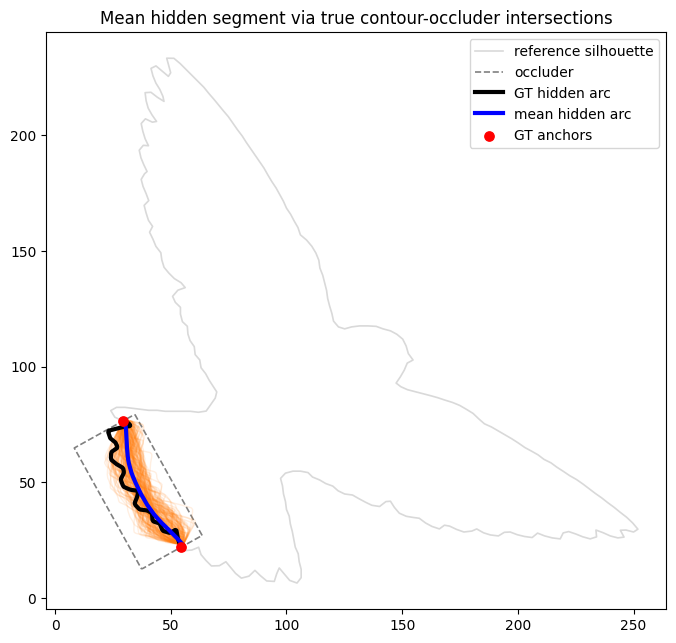

In [77]:
# %%
gt_arc_plot = resample_contour_arc_length(gt_hidden_arc, n_points=N_ARC, closed=False)

fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(
    sil_px[:, 0],
    sil_px[:, 1],
    color="0.85",
    lw=1.2,
    label="reference silhouette",
)

ax.plot(
    occ_closed[:, 0],
    occ_closed[:, 1],
    "--",
    color="0.5",
    lw=1.2,
    label="occluder",
)

for arc in hidden_arcs_resampled:
    ax.plot(
        arc[:, 0],
        arc[:, 1],
        alpha=0.12,
        lw=1.0,
        color="tab:orange",
    )

ax.plot(
    gt_arc_plot[:, 0],
    gt_arc_plot[:, 1],
    color="black",
    lw=3,
    label="GT hidden arc",
)

ax.plot(
    mean_hidden_arc[:, 0],
    mean_hidden_arc[:, 1],
    color="blue",
    lw=3,
    label="mean hidden arc",
)

ax.scatter(
    [common_start[0], common_end[0]],
    [common_start[1], common_end[1]],
    color="red",
    s=45,
    zorder=5,
    label="GT anchors",
)

ax.set_aspect("equal")
ax.set_title("Mean hidden segment via true contour-occluder intersections")
ax.legend()
plt.show()

In [78]:
# %%
import json
from pathlib import Path
import numpy as np


def orient_open_arc_to_endpoints(arc, start_xy, end_xy):
    arc = np.asarray(arc, dtype=float)
    start_xy = np.asarray(start_xy, dtype=float)
    end_xy = np.asarray(end_xy, dtype=float)

    d_forward = np.sum((arc[0] - start_xy) ** 2) + np.sum((arc[-1] - end_xy) ** 2)
    d_reverse = np.sum((arc[-1] - start_xy) ** 2) + np.sum((arc[0] - end_xy) ** 2)

    if d_reverse < d_forward:
        return arc[::-1].copy()
    return arc.copy()


def concat_open_arcs(a, b, tol=1e-8):
    """
    Concatenate two open arcs that share an endpoint.
    Avoids duplicating the join point.
    """
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    if len(a) == 0:
        return b.copy()
    if len(b) == 0:
        return a.copy()

    if np.linalg.norm(a[-1] - b[0]) <= tol:
        return np.vstack([a, b[1:]])
    return np.vstack([a, b])


def close_polyline(xy, tol=1e-8):
    xy = np.asarray(xy, dtype=float)
    if len(xy) == 0:
        return xy.copy()
    if np.linalg.norm(xy[0] - xy[-1]) <= tol:
        return xy.copy()
    return np.vstack([xy, xy[0]])


# ------------------------------------------------------------------
# Recompute the two GT candidate paths so we can get the visible path
# ------------------------------------------------------------------
path_a, path_b = split_closed_contour_between_points(sil_res, gt_p1, gt_p2)

frac_a = inside_fraction(path_a, occ_poly)
frac_b = inside_fraction(path_b, occ_poly)

if frac_a >= frac_b:
    gt_hidden_raw = path_a
    gt_visible_raw = path_b
else:
    gt_hidden_raw = path_b
    gt_visible_raw = path_a

# orient explicitly
gt_hidden_arc_save = orient_open_arc_to_endpoints(gt_hidden_raw, common_start, common_end)
gt_visible_arc_save = orient_open_arc_to_endpoints(gt_visible_raw, common_end, common_start)

# mean segment should also be explicitly oriented
mean_hidden_arc_save = orient_open_arc_to_endpoints(mean_hidden_arc, common_start, common_end)

# build full closed shape:
# hidden segment goes start -> end
# visible remainder goes end -> start
global_shape_filled_mean = concat_open_arcs(mean_hidden_arc_save, gt_visible_arc_save)
global_shape_filled_mean = close_polyline(global_shape_filled_mean)

# use the exact common anchors for saved intersections
intersection_points_xy = np.vstack([common_start, common_end])

# ------------------------------------------------------------------
# Save one JSONL row
# ------------------------------------------------------------------
save_path = RESULTS_DIR / "mean_hidden_geometry.jsonl"

record = {
    "case_id": CASE_ID,
    "target_k": int(TARGET_K),
    "n_shapes_averaged": int(len(hidden_arcs_resampled)),

    "gt_hidden_segment_xy": gt_hidden_arc_save.tolist(),
    "occluder_xy": occ_px_resampled.tolist(),
    "intersection_points_xy": intersection_points_xy.tolist(),
    "mean_hidden_segment_xy": mean_hidden_arc_save.tolist(),
    "global_shape_filled_mean_xy": global_shape_filled_mean.tolist(),
}

with open(save_path, "w", encoding="utf-8") as f:
    f.write(json.dumps(record) + "\n")

print(f"Saved JSONL to: {save_path}")
print("Keys:", list(record.keys()))
print("global_shape_filled_mean shape:", global_shape_filled_mean.shape)

Saved JSONL to: /home/hschatzle/monte-carlo-selection/results/sweep/bgmm_bird_136_symmetrical_shape_8/bird_136_symmetrical_8_1/mean_hidden_geometry.jsonl
Keys: ['case_id', 'target_k', 'n_shapes_averaged', 'gt_hidden_segment_xy', 'occluder_xy', 'intersection_points_xy', 'mean_hidden_segment_xy', 'global_shape_filled_mean_xy']
global_shape_filled_mean shape: (1178, 2)
